# Sales Data Analysis Using Python

## Project Objective
This project analyzes sales data to understand revenue,
top products, and regional performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Sales-Data.csv")

In [6]:
df.head()

,Order_ID,Order_Date,Region,Category,Product_Name,Quantity,Unit_Price,Discount_Rate,Total_Sales,Payment_Method
0,ORD0001,2024-04-14,East,Electronics,Laptop,5,297.65,0.05,1413.84,Bank Transfer
1,ORD0002,2025-07-28,West,Electronics,Laptop,2,266.27,0.00,532.54,Bank Transfer
2,ORD0003,2024-06-12,South,Office Supplies,Stapler,10,337.44,0.00,3374.40,Mobile Payment
3,ORD0004,2024-04-14,East,Furniture,Desk,4,1148.87,0.10,4135.93,Bank Transfer
4,ORD0005,2025-04-15,East,Electronics,Tablet,6,726.45,0.00,4358.70,Bank Transfer


In [7]:
df.columns

Index(['Order_ID', 'Order_Date', 'Region', 'Category', 'Product_Name',
       'Quantity', 'Unit_Price', 'Discount_Rate', 'Total_Sales',
       'Payment_Method'],
      dtype='object')

In [8]:
df.shape

(500, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        500 non-null    object 
 1   Order_Date      500 non-null    object 
 2   Region          500 non-null    object 
 3   Category        500 non-null    object 
 4   Product_Name    500 non-null    object 
 5   Quantity        500 non-null    int64  
 6   Unit_Price      500 non-null    float64
 7   Discount_Rate   500 non-null    float64
 8   Total_Sales     500 non-null    float64
 9   Payment_Method  500 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 39.2+ KB


In [10]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Region            0
Category          0
Product_Name      0
Quantity          0
Unit_Price        0
Discount_Rate     0
Total_Sales       0
Payment_Method    0
dtype: int64

In [11]:
df = df.dropna()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [14]:
df.dtypes

Order_ID           object
Order_Date         object
Region             object
Category           object
Product_Name       object
Quantity            int64
Unit_Price        float64
Discount_Rate     float64
Total_Sales       float64
Payment_Method     object
dtype: object

In [15]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        500 non-null    object        
 1   Order_Date      500 non-null    datetime64[ns]
 2   Region          500 non-null    object        
 3   Category        500 non-null    object        
 4   Product_Name    500 non-null    object        
 5   Quantity        500 non-null    int64         
 6   Unit_Price      500 non-null    float64       
 7   Discount_Rate   500 non-null    float64       
 8   Total_Sales     500 non-null    float64       
 9   Payment_Method  500 non-null    object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 39.2+ KB


In [17]:
df["Total_Sales"].sum()

np.float64(1545249.0)

In [18]:
df["Total_Sales"].mean()

np.float64(3090.498)

In [19]:
Sales_Region = df.groupby("Region")["Total_Sales"].sum()
Sales_Region

Region
East     360946.33
North    386132.85
South    412588.32
West     385581.50
Name: Total_Sales, dtype: float64

In [20]:
Sales_Category = df.groupby("Category")["Total_Sales"].sum()
Sales_Category

Category
Accessories        402949.90
Electronics        365441.85
Furniture          441418.94
Office Supplies    335438.31
Name: Total_Sales, dtype: float64

In [21]:
Top_Products = df.groupby("Product_Name")["Total_Sales"].sum().sort_values(ascending = False).head(10)
Top_Products

Product_Name
Desk              158814.06
Tablet            125001.29
Keyboard          117961.73
Filing Cabinet    111112.78
Webcam            110934.43
Printer Paper     104559.44
Pen Pack           97056.19
Laptop             92595.93
Bookshelf          89659.83
Mouse              88736.84
Name: Total_Sales, dtype: float64

In [22]:
Payment_Method = df.groupby("Payment_Method")["Total_Sales"].sum()
Payment_Method

Payment_Method
Bank Transfer     354775.84
Cash              404409.89
Credit Card       345797.03
Mobile Payment    440266.24
Name: Total_Sales, dtype: float64

In [23]:
Avg_Order = df["Total_Sales"].mean()
Avg_Order

np.float64(3090.498)

In [24]:
avg_discount = df["Discount_Rate"].mean()
avg_discount

np.float64(0.07690000000000001)

In [25]:
payment_count = df["Payment_Method"].value_counts()
payment_count

Payment_Method
Mobile Payment    139
Cash              138
Bank Transfer     114
Credit Card       109
Name: count, dtype: int64

In [26]:
avg_price_category = df.groupby("Category")["Unit_Price"].mean()
avg_price_category

Category
Accessories        601.653630
Electronics        565.967381
Furniture          622.934923
Office Supplies    614.399725
Name: Unit_Price, dtype: float64

In [27]:
Avg_Disc_Rate = df["Discount_Rate"].sum()
Avg_Disc_Rate

np.float64(38.45)

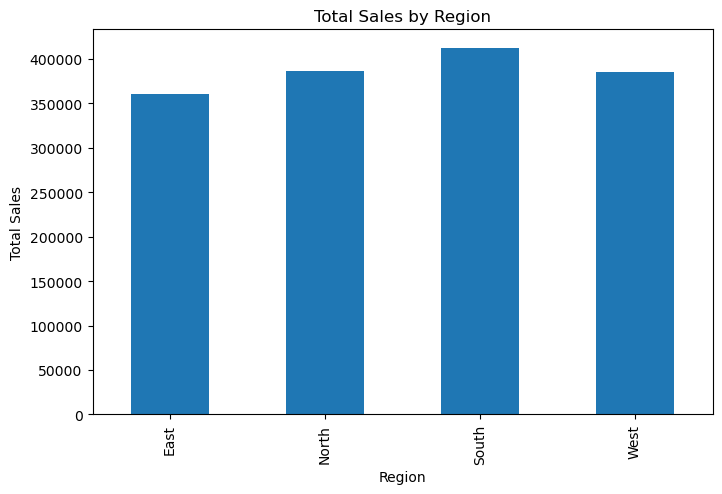

In [30]:
Sales_Region.plot(kind="bar", figsize=(8,5))
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

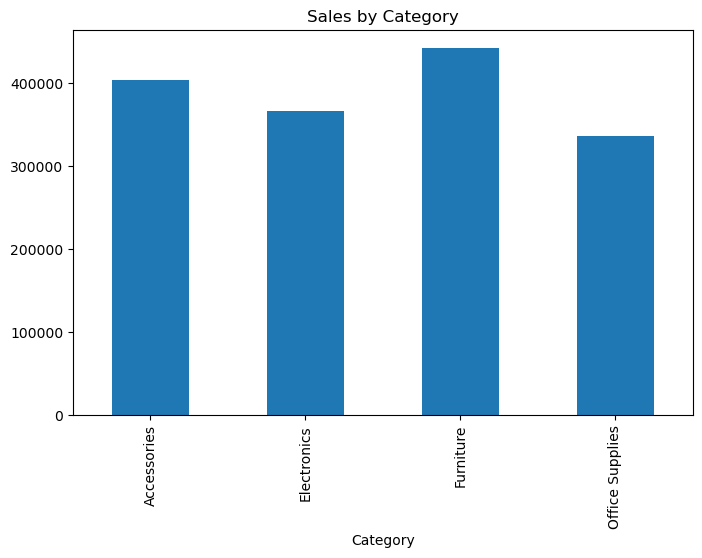

In [32]:
Sales_Category.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Category")
plt.show()

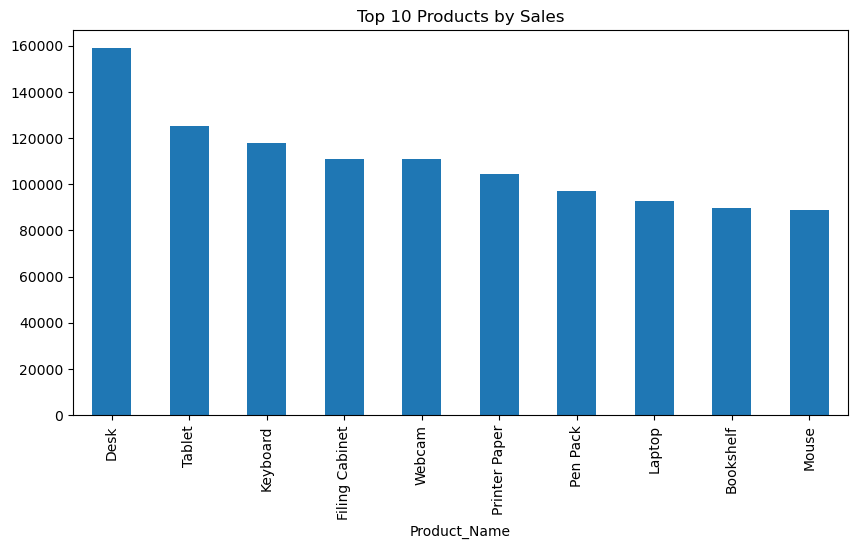

In [35]:
Top_Products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.show()

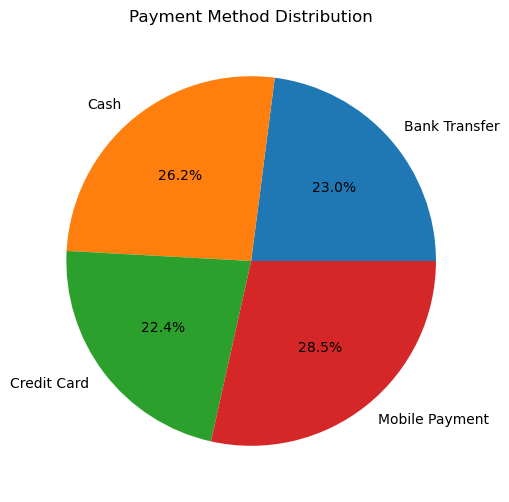

In [36]:
Payment_Method.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

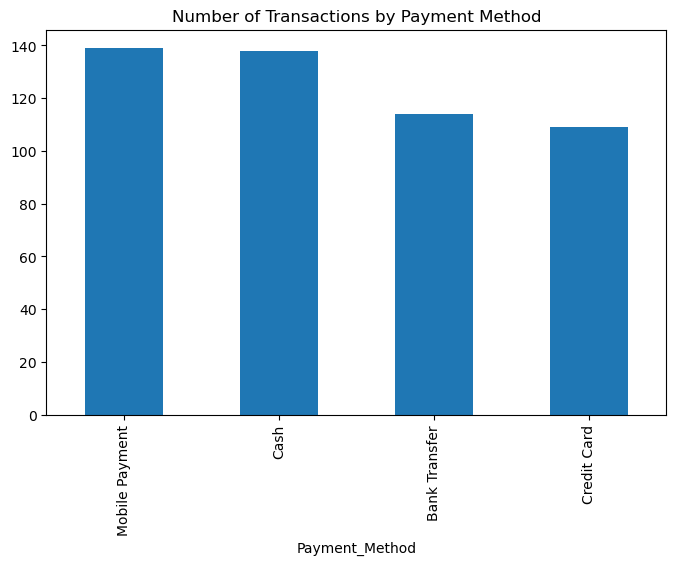

In [37]:
payment_count.plot(kind="bar", figsize=(8,5))
plt.title("Number of Transactions by Payment Method")
plt.show()

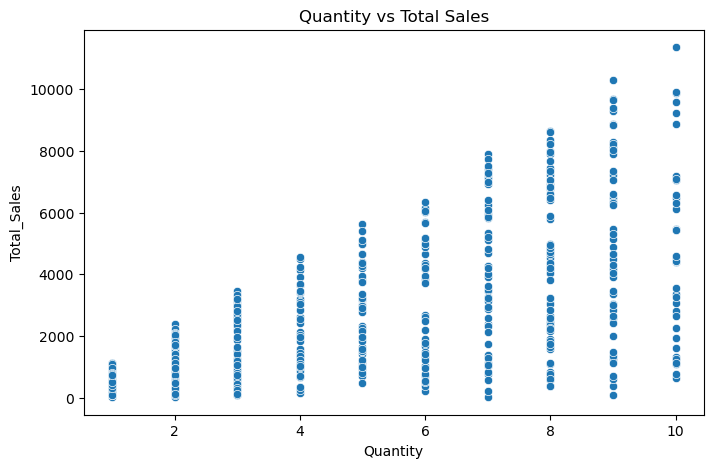

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Quantity', y='Total_Sales', data=df)
plt.title("Quantity vs Total Sales")
plt.show()

## Key Insights

• West region generated the highest total sales.

• Electronics category contributed the most revenue.

• The top 10 products account for a large portion of total sales.

• Credit Card is the most frequently used payment method.

• The average discount rate is relatively low.

## Conclusion

This project analyzed sales data to understand business performance across
different regions, categories, and products.

The analysis revealed that certain regions generate higher revenue,
while specific product categories dominate total sales. Payment method
analysis also showed customer preferences in transactions.

These insights can help businesses focus on high-performing regions and
products to improve overall sales performance.